# 01 · Análise Exploratória de Dados

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autor(es):** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Data de criação:** 21/05/2026
**Última atualização:** 28/07/2026

## Objetivo

Caracterizar o histórico de 122.543 incidentes registrados entre janeiro de 2023 e dezembro de 2025, identificando padrões de volume, sazonalidade e concentração operacional. A análise fundamenta as decisões de modelagem preditiva e examina em detalhe a mudança de patamar de volume observada a partir de setembro de 2025.

## Dependências

- Python 3.11+
- pandas, numpy, matplotlib, plotly, holidays
- openpyxl (leitura do Excel)

## Entradas

- `assets/Materal LocalWeb/LW-DATASET.xlsx` (aba `Dataset Geral`): 122.543 incidentes e 19 atributos, cobrindo três anos de operação. Cada registro descreve um incidente: prioridade, produto, categoria, equipe responsável, marcos temporais (abertura, resolução e encerramento), origem (manual ou monitoramento) e indicadores de KPI.

## Saídas

- Figuras exportadas para `notebooks/figures/01_eda/` (usadas em slides e documentos)

In [1]:
%matplotlib inline

# Stdlib
import warnings
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.io as pio
import plotly.graph_objects as go
import holidays

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Setup

Definição dos caminhos de dados e do padrão visual das figuras (paleta, tipografia e layout).

In [2]:
# --- Paths do projeto ---
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = REPO_ROOT / 'assets' / 'Materal LocalWeb' / 'LW-DATASET.xlsx'
FIGURES_DIR = NOTEBOOK_DIR / 'figures' / '01_eda'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'DATA_PATH  : {DATA_PATH}  (existe: {DATA_PATH.exists()})')
print(f'FIGURES_DIR: {FIGURES_DIR}')

REPO_ROOT  : C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb
DATA_PATH  : C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb\assets\Materal LocalWeb\LW-DATASET.xlsx  (existe: True)
FIGURES_DIR: C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb\notebooks\figures\01_eda


In [3]:
# --- Identidade visual Cronos (paleta + tipografia + layout) ---
CRONOS_COLORS = {
    'black':      '#000000',
    'dark_gray':  '#444444',
    'mid_gray':   '#888888',
    'light_gray': '#F7F7F7',
    'white':      '#FFFFFF',
    'accent':     '#2563EB',  # azul Cronos, cor de destaque
    'danger':     '#DC2626',  # vermelho, perigo/critico
    'success':    '#16A34A',
    'warning':    '#D97706',
}


def setup_cronos_style():
    """Aplica o estilo visual do Cronos ao Matplotlib."""
    mpl.rcParams.update({
        'figure.figsize': (10, 5),
        'figure.dpi': 100,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#444444',
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.titlelocation': 'left',
        'axes.titlepad': 16,
        'axes.labelsize': 12,
        'axes.labelcolor': '#444444',
        'axes.grid': True,
        'axes.axisbelow': True,
        'grid.color': '#E5E5E5',
        'grid.linewidth': 0.5,
        'xtick.color': '#888888',
        'ytick.color': '#888888',
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Sora', 'Segoe UI', 'DejaVu Sans'],
        'font.size': 11,
        'legend.frameon': False,
        'legend.fontsize': 11,
    })
    plt.rcParams['axes.grid.axis'] = 'y'


setup_cronos_style()

# Template Plotly equivalente
CRONOS_TEMPLATE = go.layout.Template(
    layout=dict(
        font=dict(family='Sora, Segoe UI, sans-serif', size=12, color='#444444'),
        title=dict(font=dict(size=18, color='#000000'), x=0.02, xanchor='left'),
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis=dict(
            showgrid=False,
            linecolor='#444444',
            tickcolor='#888888',
            tickfont=dict(size=11, color='#888888'),
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='#E5E5E5',
            gridwidth=0.5,
            linecolor='#444444',
            tickcolor='#888888',
            tickfont=dict(size=11, color='#888888'),
        ),
        colorway=['#2563EB', '#000000', '#888888', '#DC2626', '#16A34A', '#D97706'],
    )
)
pio.templates['cronos'] = CRONOS_TEMPLATE
pio.templates.default = 'cronos'

print('Estilo Cronos aplicado (Matplotlib + Plotly).')

Estilo Cronos aplicado (Matplotlib + Plotly).


## 2. Carga dos dados

Carregamento da base bruta de incidentes, sem transformações nesta etapa.

In [4]:
df = pd.read_excel(DATA_PATH, sheet_name='Dataset Geral')
print(f'Linhas: {len(df):,} | Colunas: {df.shape[1]}')

Linhas: 122,543 | Colunas: 19


## 3. Visão geral

Estrutura da base, tipos de dados, estatísticas descritivas e completude dos campos, como verificação preliminar às análises.

In [5]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Número,122543,122543,INC7227672,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prioridade,122543,5,4 - Baixa,64828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Produto,44608,51,lhco,12835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Categoria,44822,141,cat71,7335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subcategoria,44823,447,sub7,4668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo designado,122543,17,Team14,92775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item de configuração,120763,9171,IC00014,6069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aberto,122543,NaN,NaN,NaN,2025-09-18 22:10:35.012746752,2023-01-02 20:19:58,2025-09-02 10:30:35,2025-10-14 00:11:49,2025-11-26 18:11:42.500000,2025-12-31 23:45:18,NaN
Resolvido,40241,NaN,NaN,NaN,2025-06-30 07:35:15.915683328,2024-12-27 00:50:52,2025-03-26 08:17:00,2025-07-01 13:51:22,2025-10-01 16:07:13,2025-12-31 19:36:58,NaN
Encerrado,122543,NaN,NaN,NaN,2025-09-22 18:42:48.700783104,2025-01-01 00:10:45,2025-09-03 18:35:03.500000,2025-10-15 23:55:36,2025-11-28 01:53:03,2025-12-31 23:45:32,NaN


In [8]:
df.isna().sum().sort_values(ascending=False)

Incidente Pai           107416
Solução                 107243
KPI Violado?             96943
Resolvido                82302
Código de fechamento     81739
Produto                  77935
Categoria                77721
Subcategoria             77720
Item de configuração      1780
Prioridade                   0
Número                       0
Duração                      0
Encerrado                    0
Aberto                       0
Grupo designado              0
Aberto por                   0
Descrição resumida           0
Status                       0
Entrou para KPI?             0
dtype: int64

## 4. Análises

Cada subseção parte de uma pergunta, apresenta a evidência e conclui com o achado.

- 4.1 Distribuição temporal e concentração do volume
- 4.2 Anomalia em setembro de 2025 e sua causa
- 4.3 Sazonalidade: dia útil, fim de semana e feriado
- 4.4 Distribuição por prioridade, status e origem
- 4.5 Concentração por produto e por equipe
- 4.6 Violações de OLA nos incidentes elegíveis ao KPI

In [9]:
# Funções auxiliares de visualização (título/subtítulo e barras horizontais).
def titulo_cronos(ax, main, sub):
    """Título à esquerda + subtítulo factual de uma linha."""
    ax.set_title(main, loc="left", pad=34, fontsize=15, fontweight="bold", color="#000000")
    ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=10.5, color="#5f5f5f", va="bottom")

def hbar_cronos(ax, serie, destaque=None):
    """Barra horizontal ordenada (maior no topo), rótulos ao lado. Destaque opcional em azul."""
    s = serie.sort_values()
    cores = [CRONOS_COLORS["accent"] if (destaque is not None and k == destaque)
             else CRONOS_COLORS["dark_gray"] for k in s.index]
    ax.barh(range(len(s)), s.values, color=cores)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    for i, v in enumerate(s.values):
        ax.text(v, i, f" {int(v):,}".replace(",", "."), va="center", fontsize=9, color="#444444")


MESES_PT = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]

def rotulo_mes(ym):
    """Converte 'YYYY-MM' em 'mmm/AAAA' (ex.: '2025-01' -> 'jan/2025')."""
    ano, mes = ym.split("-")
    return f"{MESES_PT[int(mes) - 1]}/{ano}"

### 4.1 Distribuição temporal e concentração do volume

**Pergunta:** como os 122.543 incidentes se distribuem ao longo dos três anos? O volume é estável ou concentrado em algum período?

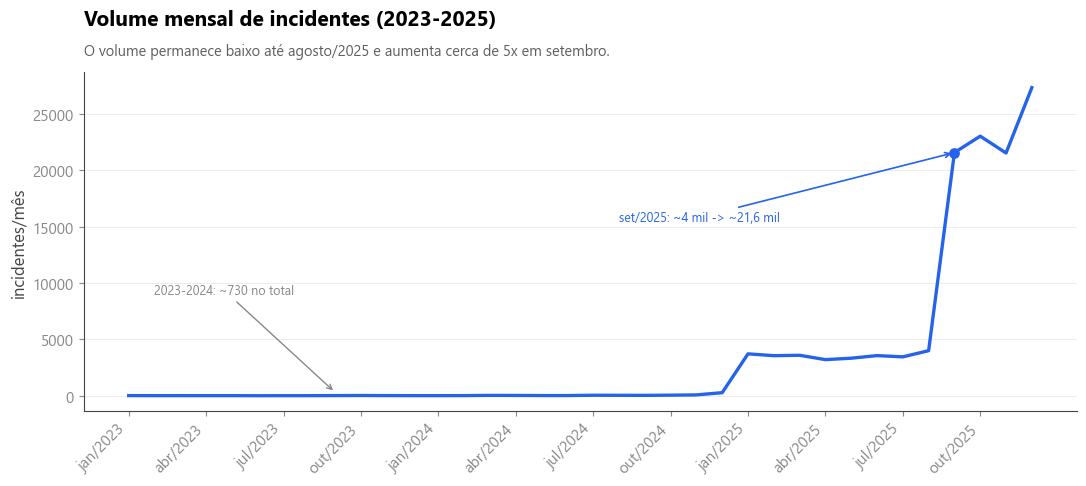

2023+2024: 732 de 122.543
ago/2025: 3996 | set/2025: 21561


In [10]:
# Volume por mês, 2023-2025. Escala normal (linha) para leitura direta do aumento.
df["mes"] = df["Aberto"].dt.to_period("M")
vol_mensal = df.groupby("mes").size()
vol_mensal.index = vol_mensal.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(vol_mensal)), vol_mensal.values, color=CRONOS_COLORS["accent"], lw=2.4)
i_set = list(vol_mensal.index).index("2025-09")
ax.scatter([i_set], [vol_mensal.iloc[i_set]], color=CRONOS_COLORS["accent"], s=45, zorder=3)
titulo_cronos(ax, "Volume mensal de incidentes (2023-2025)",
              "O volume permanece baixo até agosto/2025 e aumenta cerca de 5x em setembro.")
ax.set_ylabel("incidentes/mês")
ax.set_xticks(range(0, len(vol_mensal), 3))
ax.set_xticklabels([rotulo_mes(m) for m in vol_mensal.index[::3]], rotation=45, ha="right")
ax.annotate("set/2025: ~4 mil -> ~21,6 mil", xy=(i_set, vol_mensal.iloc[i_set]),
            xytext=(i_set - 13, vol_mensal.iloc[i_set] * 0.72), fontsize=9,
            color=CRONOS_COLORS["accent"], arrowprops=dict(arrowstyle="->", color=CRONOS_COLORS["accent"], lw=1.2))
ax.annotate("2023-2024: ~730 no total", xy=(8, 300), xytext=(1, 9000), fontsize=9,
            color=CRONOS_COLORS["mid_gray"], arrowprops=dict(arrowstyle="->", color=CRONOS_COLORS["mid_gray"], lw=1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "41_volume_mensal.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("2023+2024:", int(df[df["Aberto"].dt.year < 2025].shape[0]), "de 122.543")
print("ago/2025:", int(vol_mensal["2025-08"]), "| set/2025:", int(vol_mensal["2025-09"]))

**Achado:** o volume concentra-se no fim do período. Os anos de 2023 e 2024 somam cerca de 730 incidentes; a partir de janeiro de 2025 o total mensal passa à casa dos milhares, e em setembro de 2025 salta de aproximadamente 4 mil para 21,6 mil, cerca de cinco vezes, mantendo-se nesse patamar até dezembro. A causa dessa mudança é investigada na seção 4.2.

### 4.2 Anomalia em setembro de 2025 e sua causa

A mudança de patamar observada em setembro de 2025 foi apontada pela Locaweb como ponto de investigação prioritário.

**Pergunta:** o que muda em setembro de 2025 e explica o aumento de aproximadamente cinco vezes no volume?

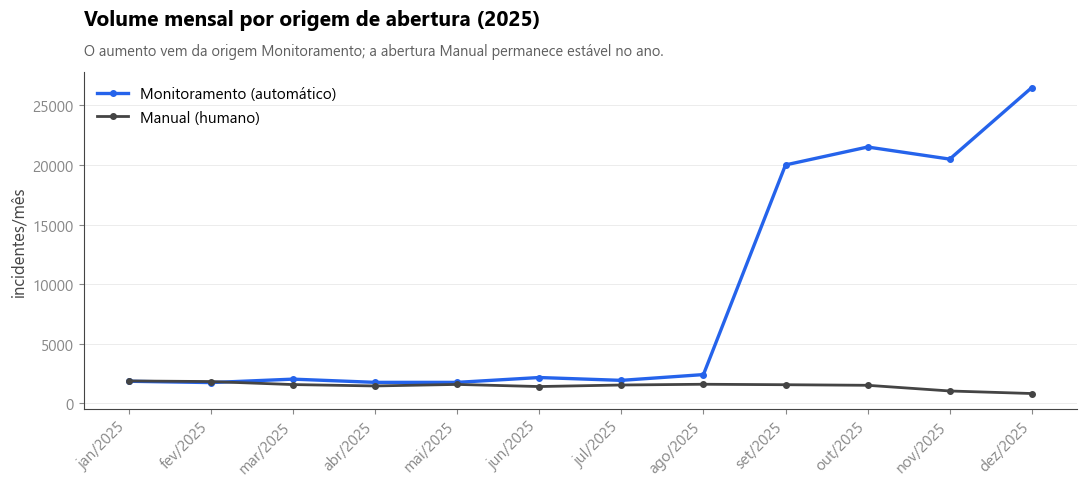

Monitoramento -> ago: 2404 | set: 20008
Manual        -> ago: 1592 | set: 1553


In [11]:
# Volume mensal por origem de abertura (Manual x Monitoramento), 2025.
meses_2025 = [f"2025-{k:02d}" for k in range(1, 13)]
df_2025 = df[df["mes"].astype(str).isin(meses_2025)].copy()
df_2025["m"] = df_2025["mes"].astype(str)
df_por_origem = df_2025.pivot_table(index="m", columns="Aberto por",
                                 values="Número", aggfunc="count", fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_por_origem))
ax.plot(x, df_por_origem["Monitoramento"], color=CRONOS_COLORS["accent"], lw=2.4, marker="o", ms=4,
        label="Monitoramento (automático)")
ax.plot(x, df_por_origem["Manual"], color=CRONOS_COLORS["dark_gray"], lw=2.0, marker="o", ms=4,
        label="Manual (humano)")
titulo_cronos(ax, "Volume mensal por origem de abertura (2025)",
              "O aumento vem da origem Monitoramento; a abertura Manual permanece estável no ano.")
ax.set_ylabel("incidentes/mês")
ax.set_xticks(list(x)); ax.set_xticklabels([rotulo_mes(m) for m in df_por_origem.index], rotation=45, ha="right")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "42a_origem.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Monitoramento -> ago:", int(df_por_origem.loc["2025-08", "Monitoramento"]),
      "| set:", int(df_por_origem.loc["2025-09", "Monitoramento"]))
print("Manual        -> ago:", int(df_por_origem.loc["2025-08", "Manual"]),
      "| set:", int(df_por_origem.loc["2025-09", "Manual"]))

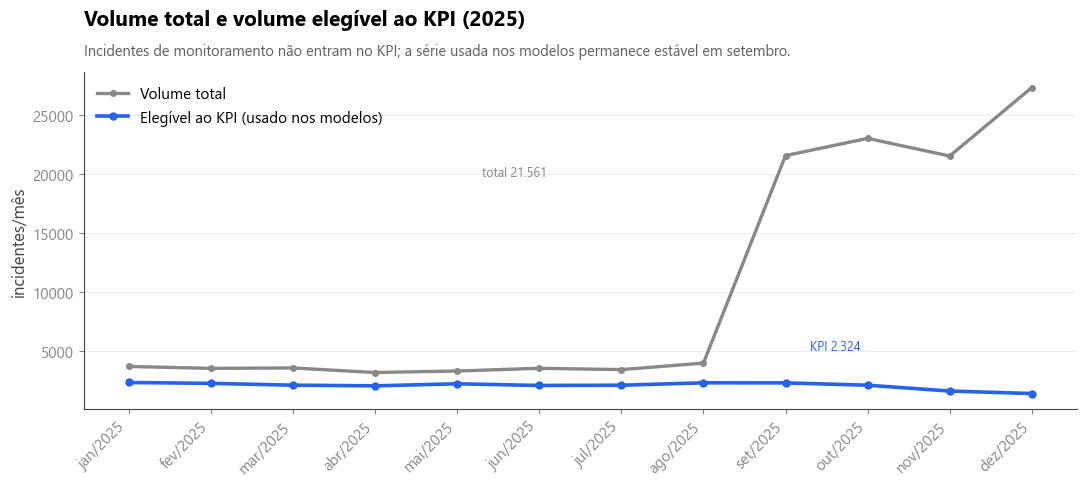

set/2025 -> total: 21561 | KPI: 2324
ago/2025 -> KPI: 2330


In [12]:
# Volume total x volume elegível ao KPI (Entrou para KPI? == "SIM"), 2025.
df_kpi = df[df["Entrou para KPI?"] == "SIM"]
vol_total = df_2025.groupby("m").size().reindex(meses_2025, fill_value=0)
vol_kpi = (df_kpi[df_kpi["mes"].astype(str).isin(meses_2025)]
           .assign(m=lambda d: d["mes"].astype(str)).groupby("m").size().reindex(meses_2025, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(meses_2025))
ax.plot(x, vol_total.values, color=CRONOS_COLORS["mid_gray"], lw=2.4, marker="o", ms=4, label="Volume total")
ax.plot(x, vol_kpi.values, color=CRONOS_COLORS["accent"], lw=2.6, marker="o", ms=5,
        label="Elegível ao KPI (usado nos modelos)")
titulo_cronos(ax, "Volume total e volume elegível ao KPI (2025)",
              "Incidentes de monitoramento não entram no KPI; a série usada nos modelos permanece estável em setembro.")
ax.set_ylabel("incidentes/mês")
ax.set_xticks(list(x)); ax.set_xticklabels([rotulo_mes(m) for m in meses_2025], rotation=45, ha="right")
ax.legend(loc="upper left")
ax.annotate(f"total {int(vol_total['2025-09']):,}".replace(",", "."), xy=(8, vol_total["2025-09"]),
            xytext=(4.3, vol_total["2025-09"] * 0.92), fontsize=9, color=CRONOS_COLORS["mid_gray"])
ax.annotate(f"KPI {int(vol_kpi['2025-09']):,}".replace(",", "."), xy=(8, vol_kpi["2025-09"]),
            xytext=(8.3, vol_kpi["2025-09"] + 2800), fontsize=9, color=CRONOS_COLORS["accent"])
fig.tight_layout()
fig.savefig(FIGURES_DIR / "42b_total_vs_kpi.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("set/2025 -> total:", int(vol_total["2025-09"]), "| KPI:", int(vol_kpi["2025-09"]))
print("ago/2025 -> KPI:", int(vol_kpi["2025-08"]))

Três verificações complementares ajudam a identificar a causa: o status dos incidentes novos, os itens de configuração que aparecem pela primeira vez em cada mês e as descrições mais frequentes de setembro.

**Pergunta:** os incidentes que surgem em setembro têm perfil de expansão de monitoramento (encerrados sem intervenção, sobre ativos antes não monitorados, com descrições de checagem automática)?

In [13]:
# Evidências complementares da causa do aumento de setembro/2025.
_m = df["mes"].astype(str)

# (a) Status "Sem Intervenção": incidente autorresolvido, sem ação humana.
sem_intervencao = (df[(df["Status"] == "Sem Intervenção") & _m.isin(meses_2025)]
                   .groupby(_m).size().reindex(meses_2025, fill_value=0))
print('(a) Incidentes com status "Sem Intervenção" por mês (2025):')
print(sem_intervencao.to_string())

# (b) Itens de configuração (ativos) vistos pela primeira vez em cada mês.
primeira_aparicao = (df.dropna(subset=["Item de configuração"])
                     .groupby("Item de configuração")["Aberto"].min()
                     .dt.to_period("M").astype(str))
ics_novos = primeira_aparicao.value_counts().sort_index().reindex(meses_2025, fill_value=0)
print("\n(b) Itens de configuração vistos pela primeira vez no mês (2025):")
print(ics_novos.to_string())

# (c) Descrições mais frequentes no mês da mudança de patamar.
print("\n(c) Top 5 descrições de setembro/2025:")
print(df[_m == "2025-09"]["Descrição resumida"].value_counts().head(5).to_string())

(a) Incidentes com status "Sem Intervenção" por mês (2025):
mes
2025-01        1
2025-02        7
2025-03        3
2025-04        1
2025-05        6
2025-06       10
2025-07        7
2025-08       47
2025-09    17838
2025-10    18964
2025-11    18508
2025-12    24978

(b) Itens de configuração vistos pela primeira vez no mês (2025):
Aberto
2025-01    1122
2025-02     739
2025-03     692
2025-04     497
2025-05     422
2025-06     428
2025-07     412
2025-08     458
2025-09    1693
2025-10    1152
2025-11     715
2025-12     525

(c) Top 5 descrições de setembro/2025:
Descrição resumida
Problem: Check Application Monitoring                    6590
Problem: High bandwidth >60% at least 15m                1874
Problem: Free disk space is less than 10% on volume /     950
Problem: Apache Busy Workers                              784
Problem: Unavailable by ICMP ping                         771


**Achado:** o aumento concentra-se na origem *Monitoramento*, que passa de 2.404 para 20.008 incidentes entre agosto e setembro, enquanto a abertura *Manual* permanece em torno de 1.500 por mês ao longo do ano. Três indicadores acompanham o mesmo movimento: o status "Sem Intervenção" cresce de 47 para 17.838; os itens de configuração vistos pela primeira vez no mês sobem de 458 para 1.693; e a descrição mais frequente do mês passa a ser "Problem: Check Application Monitoring" (6.590 ocorrências). O conjunto de evidências indica a expansão do monitoramento automático em setembro de 2025, sobre ativos que antes não eram monitorados.

**Implicação para a modelagem:** a série de incidentes elegíveis ao KPI permanece estável no período (2.330 em agosto, 2.324 em setembro). A modelagem utiliza essa série, e não o volume total, evitando que uma mudança de instrumentação seja interpretada como tendência. Os incidentes fora do KPI permanecem na base para análises complementares.

### 4.3 Sazonalidade: dia útil, fim de semana e feriado

**Pergunta:** há sazonalidade no volume diário? Ela se manifesta em dias específicos da semana ou na distinção entre dia útil e dia não útil? A análise utiliza a série de incidentes elegíveis ao KPI em 2025.

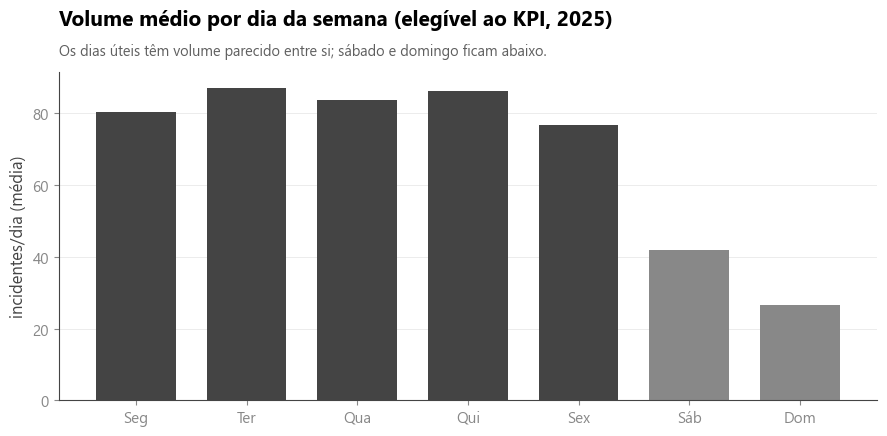

média de incidentes elegíveis por dia da semana (2025):
  Seg=80.3 | Ter=87.1 | Qua=83.7 | Qui=86.1 | Sex=76.6 | Sáb=41.8 | Dom=26.6
  faixa entre os dias úteis: 76.6 a 87.1


In [14]:
# Média de incidentes/dia por dia da semana (elegível ao KPI, 2025).
df_kpi_25 = df[(df["Entrou para KPI?"] == "SIM") & (df["Aberto"].dt.year == 2025)].copy()
df_kpi_25["date"] = df_kpi_25["Aberto"].dt.normalize()
dias_2025 = pd.date_range("2025-01-01", "2025-12-31", freq="D")
diario_kpi = df_kpi_25.groupby("date").size().reindex(dias_2025, fill_value=0)

dias_lbl = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
media_dow = diario_kpi.groupby(diario_kpi.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
cores = [CRONOS_COLORS["mid_gray"] if k >= 5 else CRONOS_COLORS["dark_gray"] for k in range(7)]
ax.bar(dias_lbl, media_dow.values, color=cores, width=0.72)
titulo_cronos(ax, "Volume médio por dia da semana (elegível ao KPI, 2025)",
              "Os dias úteis têm volume parecido entre si; sábado e domingo ficam abaixo.")
ax.set_ylabel("incidentes/dia (média)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "43a_dia_semana.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print('média de incidentes elegíveis por dia da semana (2025):')
print('  ' + ' | '.join(f'{r}={v:.1f}' for r, v in zip(dias_lbl, media_dow.values)))
print(f'  faixa entre os dias úteis: {media_dow.iloc[:5].min():.1f} a {media_dow.iloc[:5].max():.1f}')


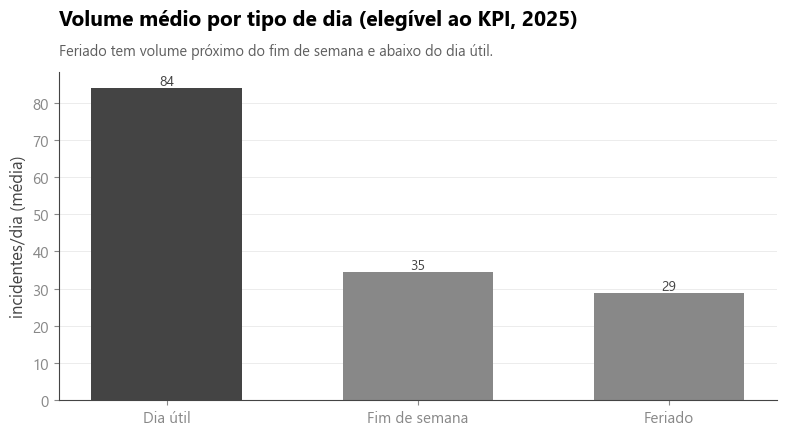

dia útil: 84.0 | fds: 34.6 | feriado: 28.8


In [15]:
# Média de incidentes/dia por tipo de dia: útil, fim de semana, feriado (BR).
feriados_br = holidays.Brazil(years=2025)
eh_feriado = pd.Series(diario_kpi.index.map(lambda d: d in feriados_br), index=diario_kpi.index)
eh_fds = pd.Series(diario_kpi.index.dayofweek >= 5, index=diario_kpi.index)
tipo_dia = pd.Series(np.where(eh_feriado, "Feriado", np.where(eh_fds, "Fim de semana", "Dia útil")),
                     index=diario_kpi.index)
media_tipo = diario_kpi.groupby(tipo_dia).mean().reindex(["Dia útil", "Fim de semana", "Feriado"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(media_tipo.index, media_tipo.values,
       color=[CRONOS_COLORS["dark_gray"], CRONOS_COLORS["mid_gray"], CRONOS_COLORS["mid_gray"]], width=0.6)
titulo_cronos(ax, "Volume médio por tipo de dia (elegível ao KPI, 2025)",
              "Feriado tem volume próximo do fim de semana e abaixo do dia útil.")
ax.set_ylabel("incidentes/dia (média)")
for i, v in enumerate(media_tipo.values):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=10, color="#444444")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "43b_tipo_dia.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("dia útil:", round(media_tipo["Dia útil"], 1), "| fds:", round(media_tipo["Fim de semana"], 1),
      "| feriado:", round(media_tipo["Feriado"], 1))

**Achado:** os dias úteis apresentam volume semelhante entre si, entre cerca de 77 e 87 incidentes por dia em 2025, enquanto sábado (42), domingo (27) e feriado (29) ficam nitidamente abaixo. O feriado aproxima-se do domingo, e não da média do fim de semana, que é de 34,6 e reúne dois dias de volume distinto. A sazonalidade distingue, portanto, dia útil de dia não útil, e não um dia específico da semana, o que orienta a construção das variáveis de calendário, combinando dia da semana e indicador de feriado.

### 4.4 Distribuição por prioridade, status e origem

**Pergunta:** como os incidentes se distribuem por prioridade, por status de encerramento e por origem de abertura?

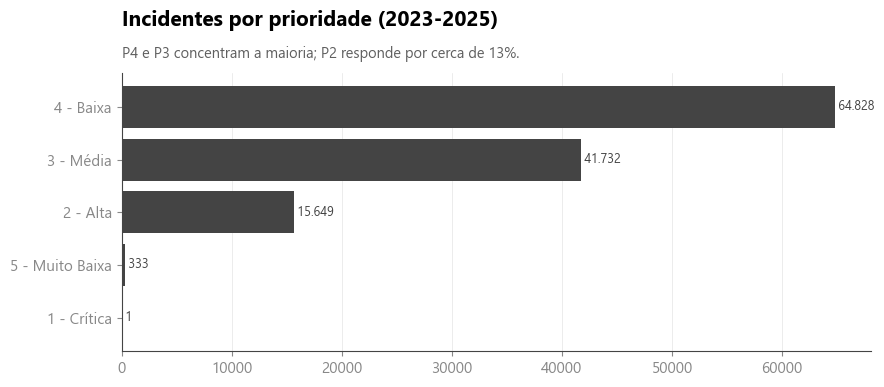

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
hbar_cronos(ax, df["Prioridade"].value_counts())
titulo_cronos(ax, "Incidentes por prioridade (2023-2025)",
              "P4 e P3 concentram a maioria; P2 responde por cerca de 13%.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "44a_prioridade.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

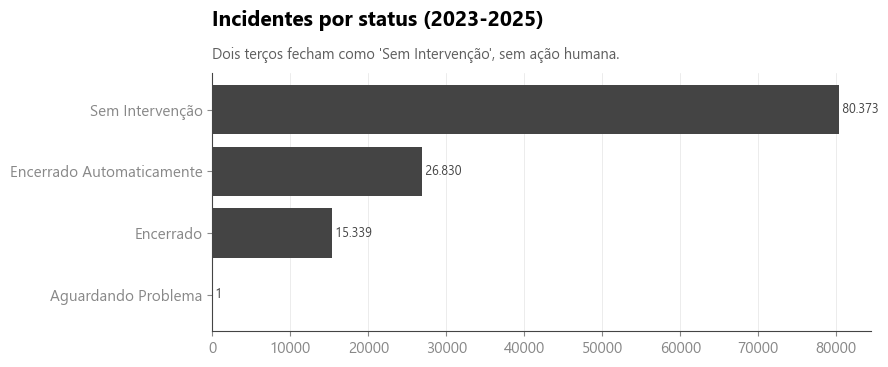

origem: {'Monitoramento': np.int64(104299), 'Manual': np.int64(18244)}


In [17]:
fig, ax = plt.subplots(figsize=(9, 3.8))
hbar_cronos(ax, df["Status"].value_counts())
titulo_cronos(ax, "Incidentes por status (2023-2025)",
              "Dois terços fecham como 'Sem Intervenção', sem ação humana.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "44b_status.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("origem:", dict(df["Aberto por"].value_counts()))

**Achado:** as prioridades P4 (52,9%) e P3 (34,1%) concentram a maior parte do volume; P2 responde por 12,8%, e P1 e P5 são residuais. Dois terços dos incidentes (65,6%) encerram como "Sem Intervenção", sem ação humana, e 85,1% originam-se de monitoramento automático. Esse perfil reforça a distinção estabelecida na seção 4.2: a maior parte do volume corresponde a eventos automáticos fora do escopo do KPI, e a modelagem concentra-se no subconjunto elegível, composto por P2 e P3 efetivamente tratados.

### 4.5 Concentração por produto e por equipe

**Pergunta:** o volume distribui-se de forma equilibrada entre equipes e produtos, ou concentra-se em poucos?

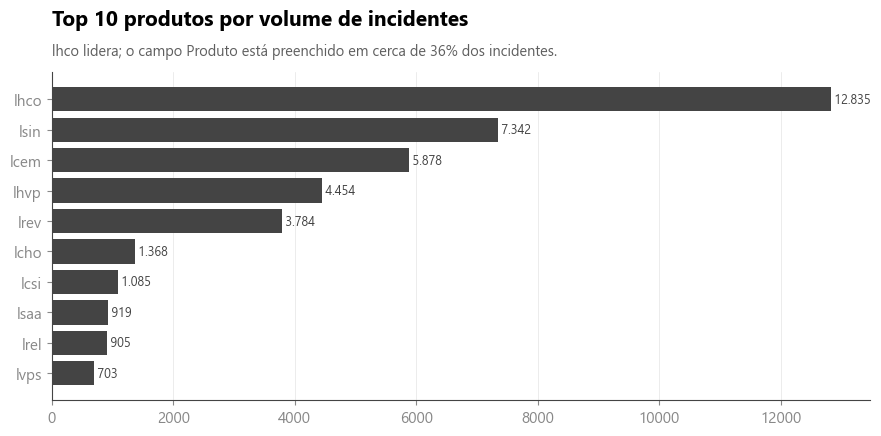

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
hbar_cronos(ax, df["Produto"].value_counts().head(10))
titulo_cronos(ax, "Top 10 produtos por volume de incidentes",
              "lhco lidera; o campo Produto está preenchido em cerca de 36% dos incidentes.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "45a_produtos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

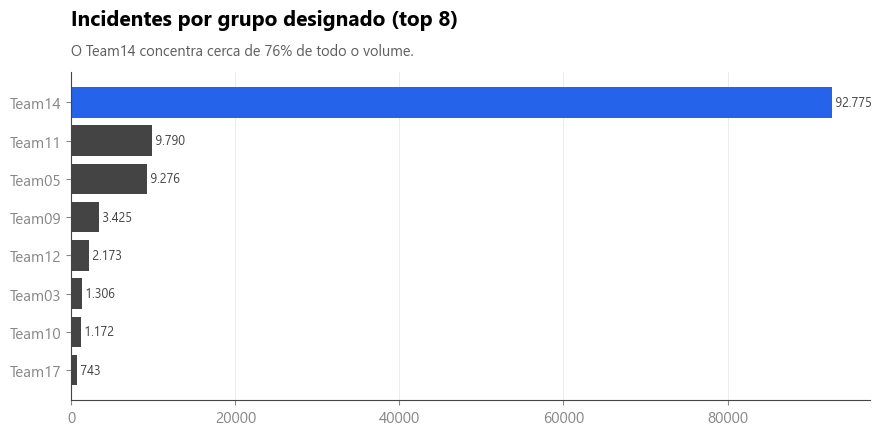

Team14: 92775 (75.7%)


In [19]:
grupos = df["Grupo designado"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4.5))
hbar_cronos(ax, grupos.head(8), destaque="Team14")
titulo_cronos(ax, "Incidentes por grupo designado (top 8)",
              "O Team14 concentra cerca de 76% de todo o volume.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "45b_grupos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Team14:", int(grupos.iloc[0]), f"({grupos.iloc[0] / len(df) * 100:.1f}%)")

**Achado:** a distribuição é acentuadamente concentrada. A equipe Team14 responde por 75,7% de todos os incidentes, com participação bem menor das demais. Entre os produtos identificados, que correspondem a cerca de 36% dos registros, lhco, lsin e lcem lideram. Essa concentração por equipe e por produto sustenta o roteamento por especialização e o índice de saúde por produto previstos na solução.

A concentração no Team14 e o preenchimento de produto em apenas 36% dos registros motivam duas investigações: o que determina o preenchimento do campo Produto e qual o papel operacional do Team14.

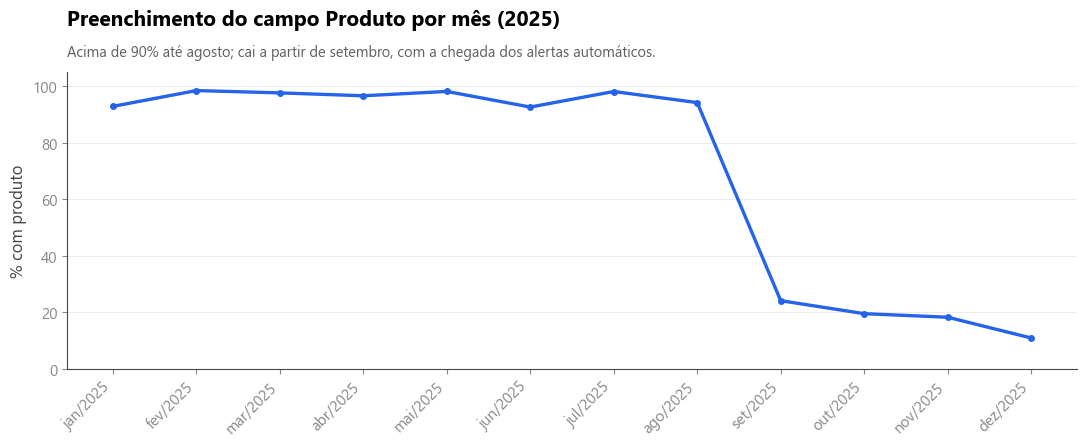

Aberto por : {'Manual': 99.4, 'Monitoramento': 25.4}
Status : {'Aguardando Problema': 100.0, 'Encerrado': 88.9, 'Encerrado Automaticamente': 98.3, 'Sem Intervenção': 5.7}
Entrou para KPI? : {'NAO': 19.7, 'SIM': 99.8}


In [20]:
# Preenchimento de Produto ao longo de 2025.
df["tem_produto"] = df["Produto"].notna()
_m = df["mes"].astype(str)
fill_mensal = (df[_m.isin(meses_2025)].groupby(_m)["tem_produto"].mean() * 100).reindex(meses_2025)

fig, ax = plt.subplots(figsize=(11, 4.6))
x = range(len(meses_2025))
ax.plot(x, fill_mensal.values, color=CRONOS_COLORS["accent"], lw=2.4, marker="o", ms=4)
titulo_cronos(ax, "Preenchimento do campo Produto por mês (2025)",
              "Acima de 90% até agosto; cai a partir de setembro, com a chegada dos alertas automáticos.")
ax.set_ylabel("% com produto"); ax.set_ylim(0, 105)
ax.set_xticks(list(x)); ax.set_xticklabels([rotulo_mes(m) for m in meses_2025], rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "45c_produto_fill.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
for col in ["Aberto por", "Status", "Entrou para KPI?"]:
    print(col, ":", (df.groupby(col)["tem_produto"].mean() * 100).round(1).to_dict())

**Achado:** o preenchimento do produto acompanha o tipo de incidente. É praticamente completo nos incidentes de origem manual (99,4%), nos status Encerrado (88,9%) e Encerrado Automaticamente (98,3%) e nos elegíveis ao KPI (99,8%), e raro nos eventos "Sem Intervenção" (5,7%). A queda a partir de setembro coincide com a expansão do monitoramento automático: os novos eventos, automáticos e autorresolvidos, não recebem classificação de produto. Como a série modelada corresponde aos incidentes elegíveis ao KPI, nos quais o produto está presente em 99,8% dos casos, a ausência de produto no volume total não afeta os modelos.

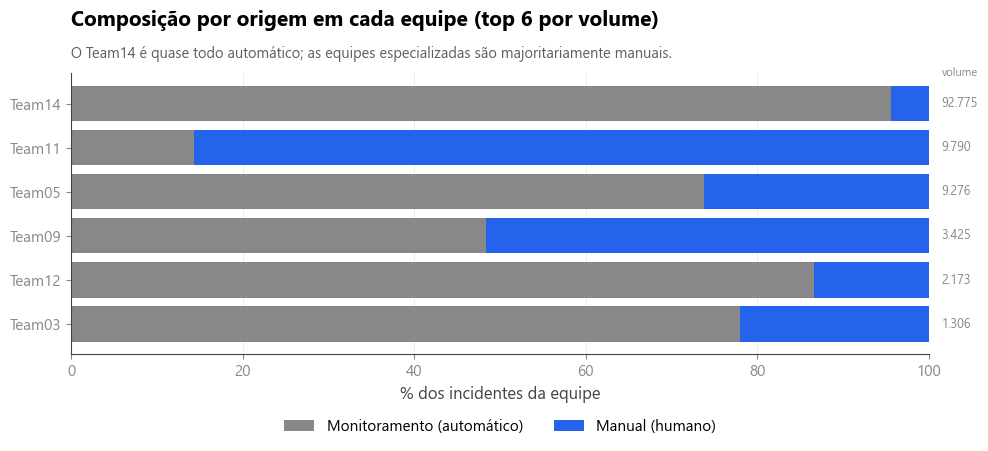

In [21]:
# Composição por origem (Monitoramento x Manual) nas seis maiores equipes.
top_eq = df["Grupo designado"].value_counts().head(6).index.tolist()
df_comp = (df[df["Grupo designado"].isin(top_eq)].groupby("Grupo designado")["Aberto por"]
        .value_counts(normalize=True).unstack().reindex(top_eq) * 100)
vol_eq = df["Grupo designado"].value_counts().reindex(top_eq)
ordem = top_eq[::-1]
df_comp = df_comp.reindex(ordem); vol_eq = vol_eq.reindex(ordem)

fig, ax = plt.subplots(figsize=(10, 4.8))
y = range(len(ordem))
ax.barh(y, df_comp["Monitoramento"], color=CRONOS_COLORS["mid_gray"], label="Monitoramento (automático)")
ax.barh(y, df_comp["Manual"], left=df_comp["Monitoramento"], color=CRONOS_COLORS["accent"], label="Manual (humano)")
ax.set_yticks(list(y)); ax.set_yticklabels(ordem); ax.set_xlim(0, 100)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for i, t in enumerate(ordem):
    ax.text(101.5, i, f"{int(vol_eq[t]):,}".replace(",", "."), va="center", fontsize=9, color="#888888")
ax.text(101.5, len(ordem) - 0.3, "volume", va="center", fontsize=8, color="#888888")
titulo_cronos(ax, "Composição por origem em cada equipe (top 6 por volume)",
              "O Team14 é quase todo automático; as equipes especializadas são majoritariamente manuais.")
ax.set_xlabel("% dos incidentes da equipe")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "45d_origem_equipe.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

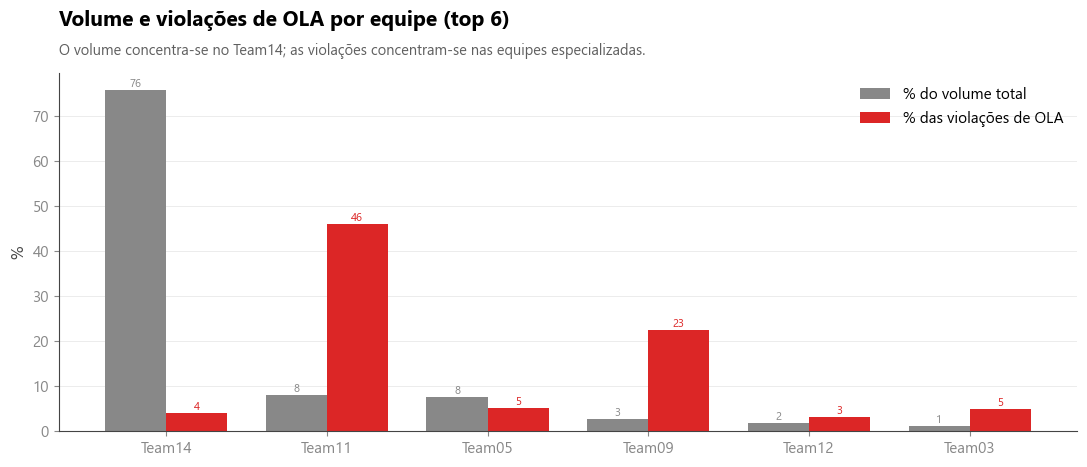

In [22]:
# Participação no volume x participação nas violações de OLA, por equipe.
viol_eq = df[df["KPI Violado?"] == "SIM"]
vol_pct = (df["Grupo designado"].value_counts() / len(df) * 100).reindex(top_eq)
ola_pct = (viol_eq["Grupo designado"].value_counts() / len(viol_eq) * 100).reindex(top_eq).fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(top_eq)); w = 0.38
ax.bar(x - w / 2, vol_pct.values, w, color=CRONOS_COLORS["mid_gray"], label="% do volume total")
ax.bar(x + w / 2, ola_pct.values, w, color=CRONOS_COLORS["danger"], label="% das violações de OLA")
titulo_cronos(ax, "Volume e violações de OLA por equipe (top 6)",
              "O volume concentra-se no Team14; as violações concentram-se nas equipes especializadas.")
ax.set_ylabel("%"); ax.set_xticks(list(x)); ax.set_xticklabels(top_eq); ax.legend(loc="upper right")
for xi, (v, o) in enumerate(zip(vol_pct.values, ola_pct.values)):
    ax.text(xi - w / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8, color="#888888")
    ax.text(xi + w / 2, o, f"{o:.0f}", ha="center", va="bottom", fontsize=8, color=CRONOS_COLORS["danger"])
fig.tight_layout()
fig.savefig(FIGURES_DIR / "45e_volume_vs_ola.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

Para verificar o papel operacional do Team14, calcula-se o perfil da equipe em quatro indicadores: origem da abertura, encerramento sem intervenção, entrada no KPI e violações de OLA.

In [23]:
# Perfil do Team14 nos quatro indicadores citados no achado a seguir.
df_t14 = df[df["Grupo designado"] == "Team14"]
print(f"Team14: {len(df_t14):,} incidentes ({len(df_t14) / len(df) * 100:.1f}% do total)")
print(f"  origem automática (Monitoramento): {(df_t14['Aberto por'] == 'Monitoramento').mean() * 100:.1f}%")
print(f"  encerrados como 'Sem Intervenção': {(df_t14['Status'] == 'Sem Intervenção').mean() * 100:.1f}%")
print(f"  entram no KPI:                     {(df_t14['Entrou para KPI?'] == 'SIM').mean() * 100:.1f}%")
print(f"  violações de OLA:                  {int((df_t14['KPI Violado?'] == 'SIM').sum())}")

Team14: 92,775 incidentes (75.7% do total)
  origem automática (Monitoramento): 95.5%
  encerrados como 'Sem Intervenção': 81.5%
  entram no KPI:                     9.7%
  violações de OLA:                  10


**Achado:** os dados sugerem uma estrutura de atendimento em dois níveis. O Team14 concentra 75,7% do volume, quase todo de origem automática (95,5%) e encerrado sem intervenção (81,5%), com baixa entrada no KPI (9,7%) e apenas 10 violações de OLA, perfil compatível com um primeiro nível (N1) que absorve os alertas automáticos. As equipes especializadas, como Team11 e Team09, processam volume menor, porém quase todo manual e classificado, e concentram as violações de OLA: o Team11 responde por 46% delas com apenas 8% do volume. O risco operacional, portanto, não acompanha o volume: concentra-se no trabalho especializado dos níveis seguintes, o que orienta onde direcionar atenção preventiva.

### 4.6 Violações de OLA nos incidentes elegíveis ao KPI

**Pergunta:** entre os incidentes que entram no KPI, quantos violam o acordo de nível de serviço (OLA) e onde essas violações se concentram?

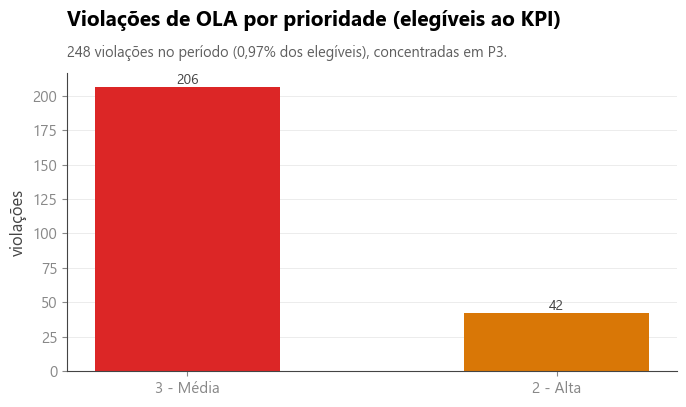

violações: 248 de 25600 elegíveis (0.97%)
por prioridade: {'3 - Média': np.int64(206), '2 - Alta': np.int64(42)}


In [24]:
df_violacoes = df[df["KPI Violado?"] == "SIM"]
df_elegiveis = df[df["Entrou para KPI?"] == "SIM"]
taxa = len(df_violacoes) / len(df_elegiveis) * 100
taxa_str = f'{taxa:.2f}'.replace('.', ',')  # formato PT-BR: 0,97
por_prio = df_violacoes["Prioridade"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(por_prio.index, por_prio.values, color=[CRONOS_COLORS["danger"], CRONOS_COLORS["warning"]][:len(por_prio)], width=0.5)
titulo_cronos(ax, "Violações de OLA por prioridade (elegíveis ao KPI)",
              f"{len(df_violacoes)} violações no período ({taxa_str}% dos elegíveis), concentradas em P3.")
ax.set_ylabel("violações")
for i, v in enumerate(por_prio.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=10, color="#444444")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "46a_ola_prioridade.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"violações: {len(df_violacoes)} de {len(df_elegiveis)} elegíveis ({taxa:.2f}%)")
print("por prioridade:", dict(por_prio))

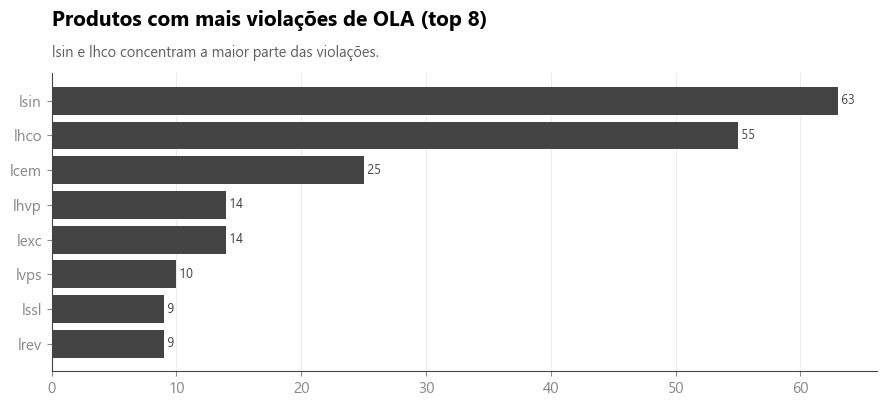

top grupos: {'Team11': np.int64(114), 'Team09': np.int64(56), 'Team07': np.int64(16)}


In [25]:
fig, ax = plt.subplots(figsize=(9, 4.2))
hbar_cronos(ax, df_violacoes["Produto"].value_counts().head(8))
titulo_cronos(ax, "Produtos com mais violações de OLA (top 8)",
              "lsin e lhco concentram a maior parte das violações.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "46b_ola_produtos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("top grupos:", dict(df_violacoes["Grupo designado"].value_counts().head(3)))

**Achado:** dos incidentes elegíveis ao KPI, 248 violaram a OLA, o equivalente a 0,97%. As violações concentram-se em P3 (206) em relação a P2 (42), nas equipes Team11 (114) e Team09 (56), e nos produtos lsin e lhco. Esse conjunto constitui a variável-alvo do modelo de risco de OLA. Por se tratar de uma base pequena e desbalanceada, 248 casos positivos em 25,6 mil elegíveis, a avaliação privilegiará precisão e recall, e não a acurácia.

## 5. Conclusões e próximos passos

### Principais achados
1. O volume é concentrado no fim do período: 2023 e 2024 somam cerca de 730 incidentes, enquanto 2025 registra milhares por mês.
2. O aumento de setembro de 2025 (aproximadamente cinco vezes) decorre da expansão do monitoramento automático (origem *Monitoramento*, status "Sem Intervenção" e cerca de 1.700 novos itens de configuração) e ocorre fora do escopo do KPI.
3. A série de incidentes elegíveis ao KPI é estável ao longo de 2025 e não é afetada pela mudança de setembro.
4. A sazonalidade distingue dia útil de dia não útil (fim de semana e feriado), e não dias específicos da semana.
5. O volume concentra-se na equipe Team14 (75,7%) e em poucos produtos (lhco, lsin, lcem).
6. As violações de OLA (248; 0,97% dos elegíveis) concentram-se em P3 e nas equipes Team11 e Team09.

### Decisões que isso implica
- O alvo dos modelos é a série diária de incidentes elegíveis ao KPI, por prioridade (P2 e P3), e não o volume total.
- As variáveis de calendário combinam dia da semana e feriado.
- O risco de OLA é um problema desbalanceado, avaliado por precisão e recall.
- O produto está presente em 99,8% dos elegíveis, o que viabiliza análises e indicadores por produto.

### Próximos passos
- Consolidar a base compartilhada dos modelos (filtro de KPI e colunas de calendário) no notebook `02_base_kpi`.
- Prever o volume diário da série elegível ao KPI (D+1 e D+7) com Prophet, usando variáveis de calendário; abordagem validada no notebook `03_previsao_volume`.
- Estimar o risco de violação de OLA com regressão logística; o XGBoost serve como baseline de comparação.
- Projetar o atingimento das metas anuais de KPI a partir das previsões de volume e risco.

### Pontos abertos / dúvidas
- O período denso e estável concentra-se em 2025; 2023 e 2024 têm volume reduzido, o que restringe a base histórica disponível para o treino.